In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv("Dataset .csv")
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCities Covered:", df["City"].nunique())
print("Country Codes:", df["Country Code"].nunique())


DATASET OVERVIEW
Rows: 9551
Columns: 21

Cities Covered: 141
Country Codes: 15


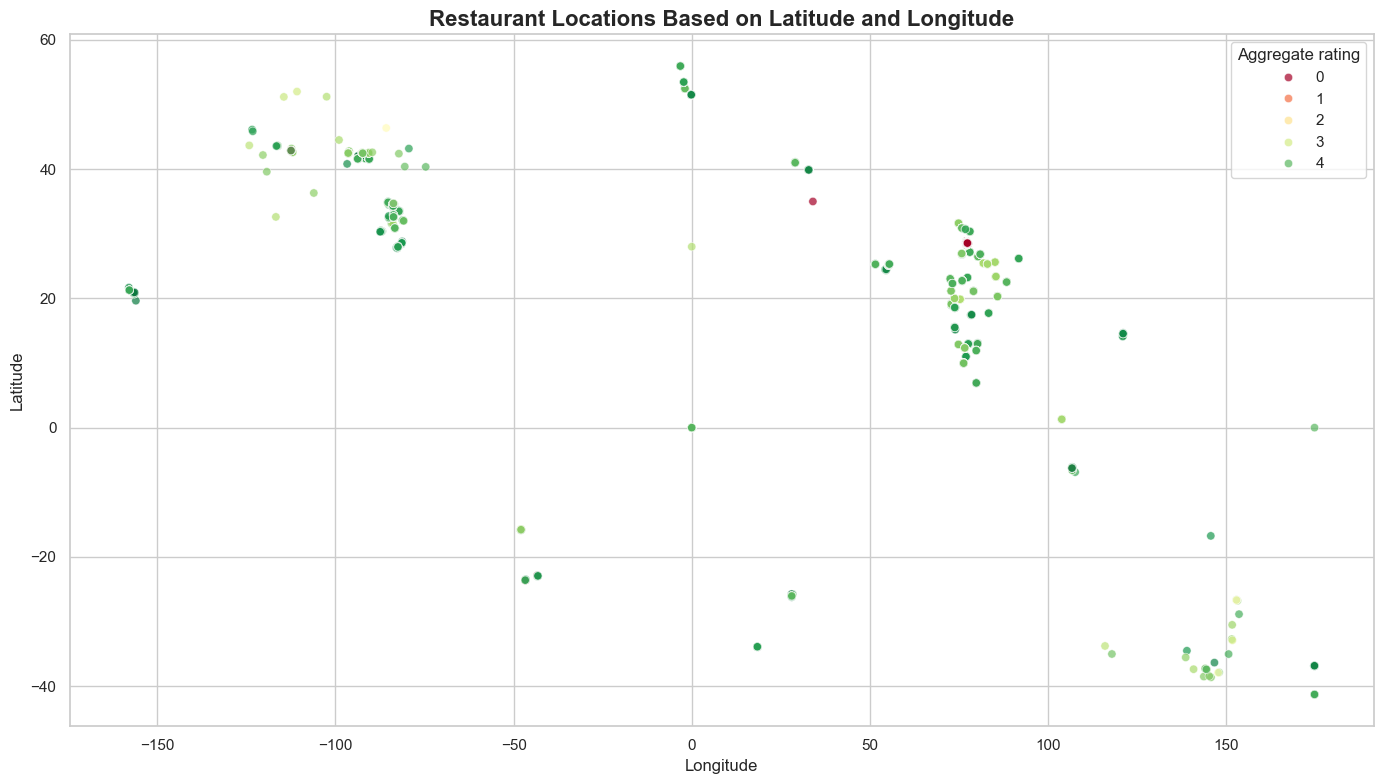

In [22]:
country_map = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Philippines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "United Arab Emirates",
    215: "United Kingdom",
    216: "United States"
}

df["Country"] = df["Country Code"].map(country_map)
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Aggregate rating",
    palette="RdYlGn",
    alpha=0.7
)

plt.title(
    "Restaurant Locations Based on Latitude and Longitude",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

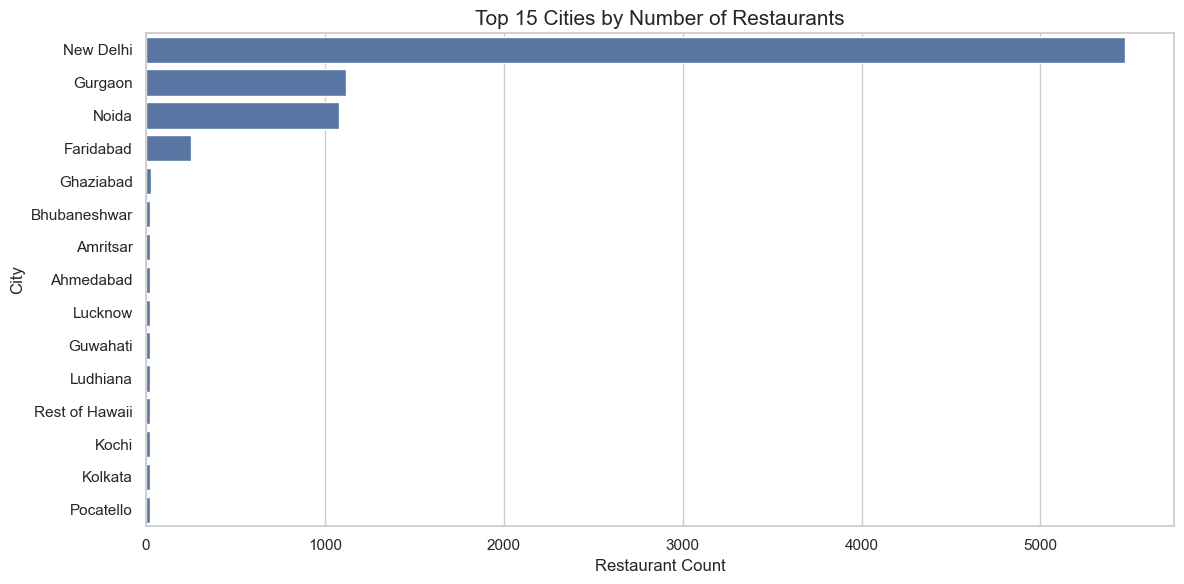


Top 10 Cities
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


In [23]:
top_cities = df["City"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title(
    "Top 15 Cities by Number of Restaurants",
    fontsize=15
)

plt.xlabel("Restaurant Count")
plt.ylabel("City")

plt.tight_layout()
plt.show()

print("\nTop 10 Cities")
print(top_cities.head(10))


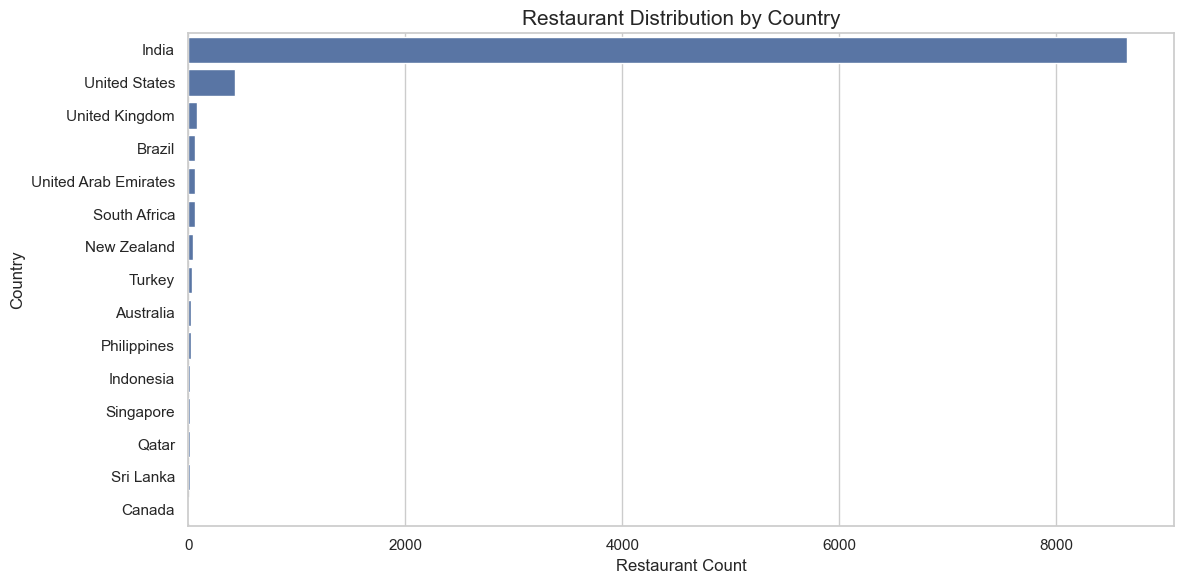


Country Distribution
Country
India                   8652
United States            434
United Kingdom            80
Brazil                    60
United Arab Emirates      60
South Africa              60
New Zealand               40
Turkey                    34
Australia                 24
Philippines               22
Indonesia                 21
Singapore                 20
Qatar                     20
Sri Lanka                 20
Canada                     4
Name: count, dtype: int64


In [24]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title(
    "Restaurant Distribution by Country",
    fontsize=15
)

plt.xlabel("Restaurant Count")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

print("\nCountry Distribution")
print(country_counts)

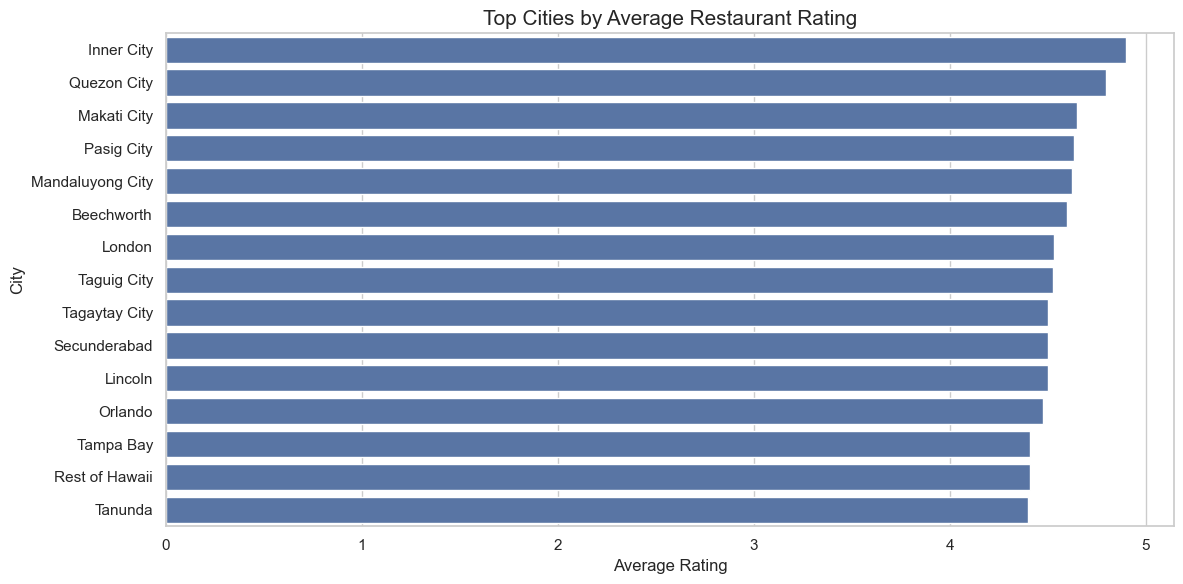

In [25]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=city_rating.values,
    y=city_rating.index
)

plt.title(
    "Top Cities by Average Restaurant Rating",
    fontsize=15
)

plt.xlabel("Average Rating")
plt.ylabel("City")

plt.tight_layout()
plt.show()


In [27]:
lat_corr, lat_p = pearsonr(
    df["Latitude"],
    df["Aggregate rating"]
)

lon_corr, lon_p = pearsonr(
    df["Longitude"],
    df["Aggregate rating"]
)

print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

print(f"""
Latitude vs Rating

Correlation Coefficient : {lat_corr:.4f}
P-Value                 : {lat_p:.4f}

Longitude vs Rating

Correlation Coefficient : {lon_corr:.4f}
P-Value                 : {lon_p:.4f}
""")



CORRELATION ANALYSIS

Latitude vs Rating

Correlation Coefficient : 0.0005
P-Value                 : 0.9598

Longitude vs Rating

Correlation Coefficient : -0.1168
P-Value                 : 0.0000



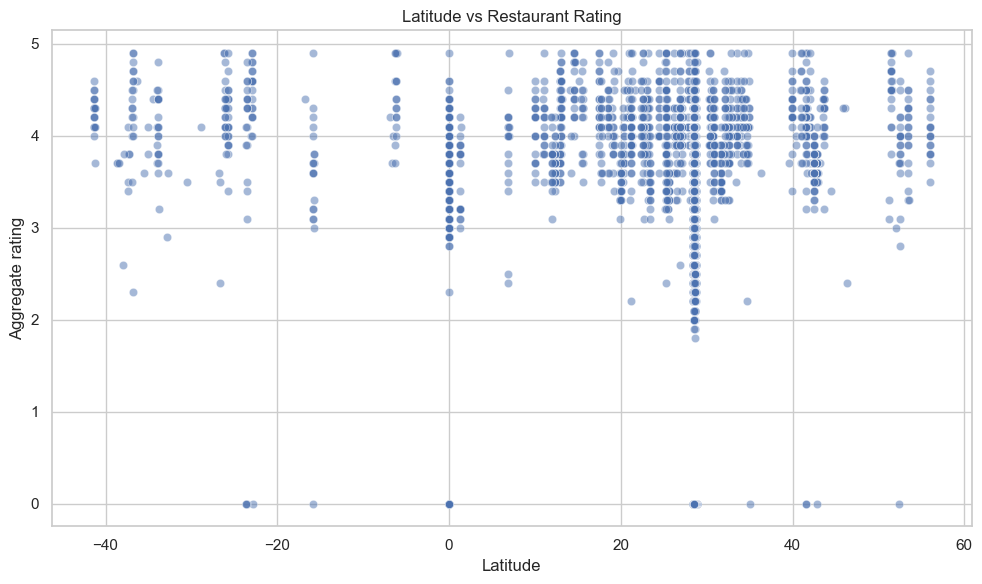

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Latitude",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Latitude vs Restaurant Rating")

plt.tight_layout()
plt.show()


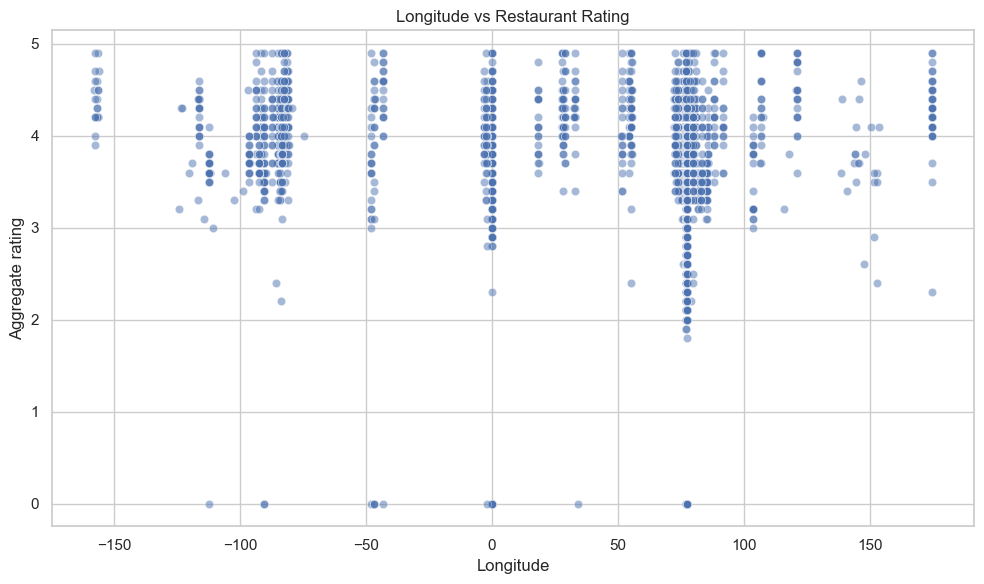

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Longitude vs Restaurant Rating")

plt.tight_layout()
plt.show()


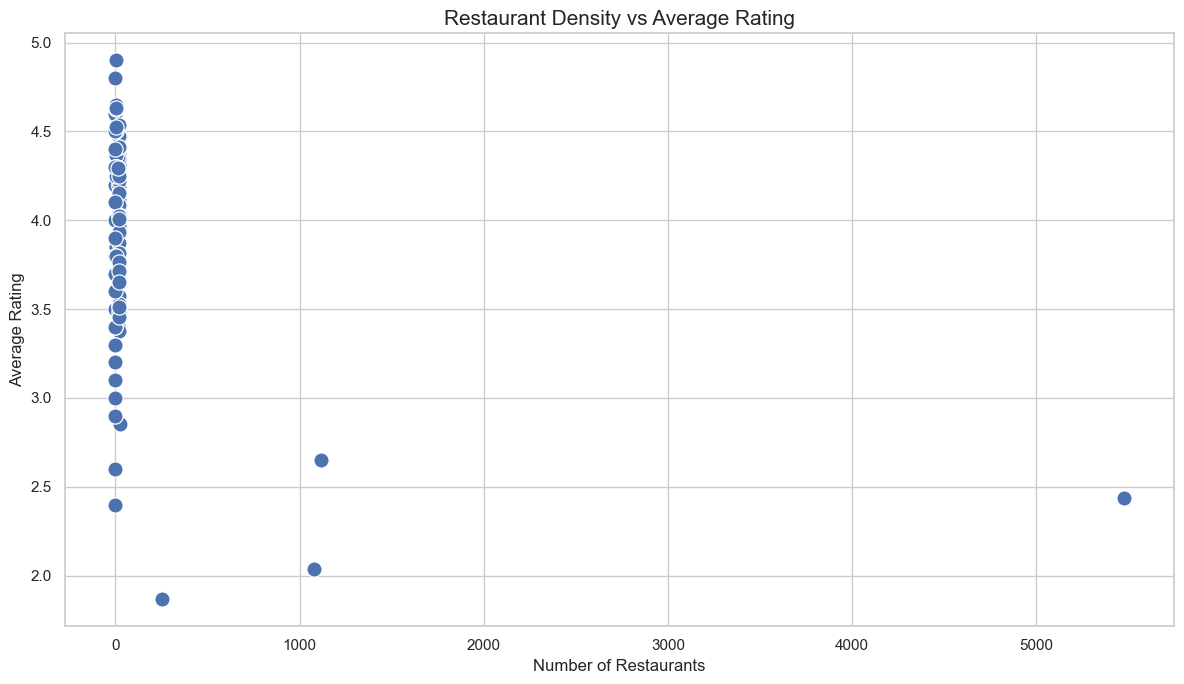

In [30]:
city_analysis = (
    df.groupby("City")
      .agg({
          "Restaurant ID":"count",
          "Aggregate rating":"mean"
      })
)

city_analysis.columns = [
    "Restaurant Count",
    "Average Rating"
]

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=city_analysis,
    x="Restaurant Count",
    y="Average Rating",
    s=120
)

plt.title(
    "Restaurant Density vs Average Rating",
    fontsize=15
)

plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

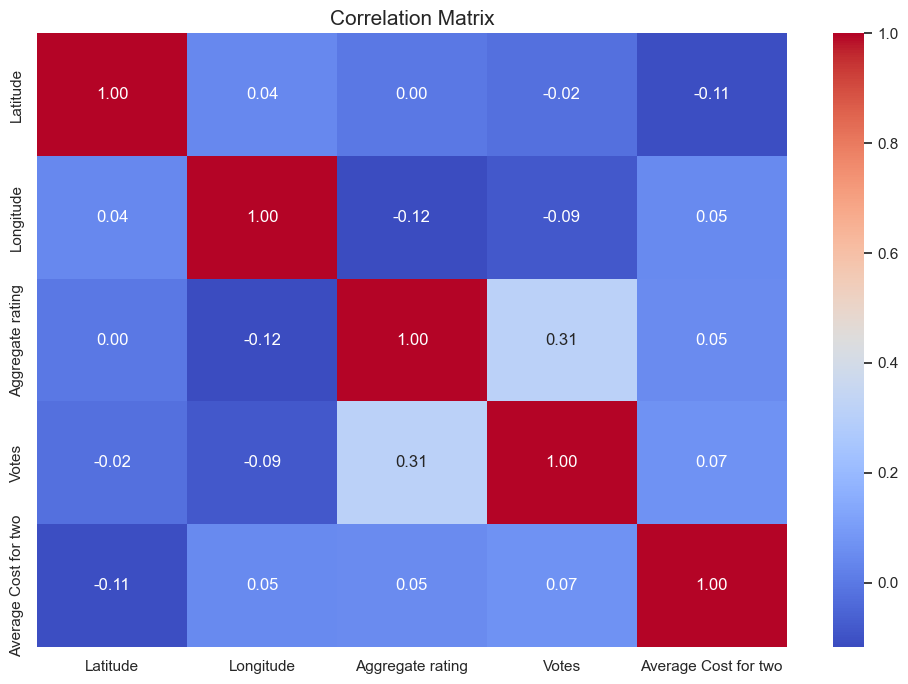

In [31]:
plt.figure(figsize=(10,7))

corr_matrix = df[
    [
        "Latitude",
        "Longitude",
        "Aggregate rating",
        "Votes",
        "Average Cost for two"
    ]
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [32]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"""
1. Total Restaurants :
   {len(df):,}
2. Total Cities :
   {df['City'].nunique()}
3. Total Countries :
   {df['Country'].nunique()}
4. City With Most Restaurants :
   {top_cities.idxmax()}
   ({top_cities.max()} Restaurants)
5. Country With Most Restaurants :
   {country_counts.idxmax()}
   ({country_counts.max()} Restaurants)
6. Highest Rated City :
   {city_rating.idxmax()}
   ({city_rating.max():.2f})
7. Latitude-Rating Correlation :
   {lat_corr:.4f}
8. Longitude-Rating Correlation :
   {lon_corr:.4f}
""")
if abs(lat_corr) < 0.30 and abs(lon_corr) < 0.30:
    print(
        "Conclusion: Restaurant ratings show a weak "
        "relationship with geographic location."
    )
else:
    print(
        "Conclusion: Geographic location appears to "
        "have some influence on restaurant ratings."
    )

print("\nGeospatial Analysis Completed Successfully!")


KEY INSIGHTS

1. Total Restaurants :
   9,551
2. Total Cities :
   141
3. Total Countries :
   15
4. City With Most Restaurants :
   New Delhi
   (5473 Restaurants)
5. Country With Most Restaurants :
   India
   (8652 Restaurants)
6. Highest Rated City :
   Inner City
   (4.90)
7. Latitude-Rating Correlation :
   0.0005
8. Longitude-Rating Correlation :
   -0.1168

Conclusion: Restaurant ratings show a weak relationship with geographic location.

Geospatial Analysis Completed Successfully!
